In [1]:
!unzip dataset.zip
!ls dataset/train
!rm -rf __MACOSXy

Archive:  dataset.zip
   creating: dataset/
  inflating: dataset/.DS_Store       
  inflating: __MACOSX/dataset/._.DS_Store  
   creating: dataset/train/
   creating: dataset/val/
   creating: dataset/train/diseased/
  inflating: dataset/train/.DS_Store  
  inflating: __MACOSX/dataset/train/._.DS_Store  
   creating: dataset/train/healthy/
   creating: dataset/val/diseased/
  inflating: dataset/val/.DS_Store   
  inflating: __MACOSX/dataset/val/._.DS_Store  
   creating: dataset/val/healthy/
  inflating: dataset/train/diseased/Unknown-10.jpeg  
  inflating: __MACOSX/dataset/train/diseased/._Unknown-10.jpeg  
  inflating: dataset/train/diseased/images-3.jpeg  
  inflating: __MACOSX/dataset/train/diseased/._images-3.jpeg  
  inflating: dataset/train/diseased/Unknown-1.jpeg  
  inflating: __MACOSX/dataset/train/diseased/._Unknown-1.jpeg  
  inflating: dataset/train/diseased/.DS_Store  
  inflating: __MACOSX/dataset/train/diseased/._.DS_Store  
  inflating: dataset/train/diseased/images.jp

Found 51 images belonging to 2 classes.
Found 18 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4314 - loss: 0.8131 - val_accuracy: 0.5556 - val_loss: 0.7078
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 910ms/step - accuracy: 0.5294 - loss: 0.8083 - val_accuracy: 0.6667 - val_loss: 0.6520
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 726ms/step - accuracy: 0.6275 - loss: 0.6028 - val_accuracy: 0.7222 - val_loss: 0.6131
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7451 - loss: 0.6184 - val_accuracy: 0.7222 - val_loss: 0.5847
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 703ms/step - accuracy: 0.6863 - loss: 0.5669 - val_accuracy: 0.7222 - val_loss: 0.5679
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 661ms/step - accuracy: 0.7647 - loss: 0.5247 - val_accuracy: 0.7222 - val_loss: 0.5546
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 664ms/step - accuracy: 0.9020 - loss: 0.3179 - val_accuracy: 0.7222 - val_loss: 0

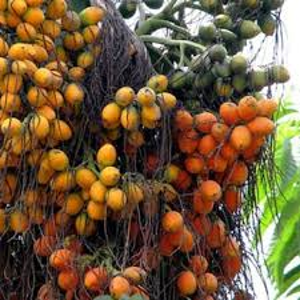

Image Result: Healthy (93.6%)

===== FINAL DECISION =====
⚠️ Plant appears healthy, but weather conditions are highly favorable for Koleroga. Monitor regularly and take preventive measures.


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from PIL import Image
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# LOAD WEATHER DATA
df = pd.read_csv("koleroga_corrected_dataset.csv")

df = df.replace(r'\\', '', regex=True)

cols = ['temperature', 'humidity', 'rainfall', 'disease']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

X = df[['temperature', 'humidity', 'rainfall']]
y = df['disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TRAIN WEATHER MODEL
weather_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

weather_model.fit(X_train, y_train)

# IMAGE DATA GENERATORS
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    "dataset/val",
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

# BUILD IMAGE MODEL
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

image_model = Model(inputs=base_model.input, outputs=output)

image_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# TRAIN IMAGE MODEL
history = image_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

print("\nClass labels:", train_generator.class_indices)

# IMAGE PREDICTION FUNCTION
def predict_image_disease(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prob = image_model.predict(img_array, verbose=0)[0][0]
    class_map = train_generator.class_indices

    if class_map['diseased'] == 1:
        if prob >= 0.5:
            return f"Diseased ({prob*100:.1f}%)"
        else:
            return f"Healthy ({(1-prob)*100:.1f}%)"
    else:
        if prob < 0.5:
            return f"Diseased ({(1-prob)*100:.1f}%)"
        else:
            return f"Healthy ({prob*100:.1f}%)"

# WEATHER DSS FUNCTION
def koleroga_dss(temperature, humidity, rainfall):
    input_data = pd.DataFrame(
        [[temperature, humidity, rainfall]],
        columns=['temperature', 'humidity', 'rainfall']
    )

    model_prob = weather_model.predict_proba(input_data)[0][1]

    if humidity <= 70:
        hum_score = 0.1
    elif humidity <= 80:
        hum_score = 0.3
    elif humidity <= 85:
        hum_score = 0.5
    elif humidity <= 90:
        hum_score = 0.7
    else:
        hum_score = 0.9

    if rainfall <= 100:
        rain_score = 0.1
    elif rainfall <= 200:
        rain_score = 0.3
    elif rainfall <= 400:
        rain_score = 0.5
    elif rainfall <= 600:
        rain_score = 0.7
    else:
        rain_score = 0.9

    if temperature < 20:
        temp_score = 0.2
    elif temperature <= 24:
        temp_score = 0.5
    elif temperature <= 28:
        temp_score = 0.8
    elif temperature <= 32:
        temp_score = 0.5
    else:
        temp_score = 0.2

    final_score = (
        0.4 * model_prob +
        0.3 * hum_score +
        0.2 * rain_score +
        0.1 * temp_score
    )


    final_score = round(final_score, 2)

    if final_score < 0.35:
        return f"✅ Low Risk ({final_score*100:.0f}%) → Normal monitoring"
    elif final_score < 0.65:
        return f"⚠️ Moderate Risk ({final_score*100:.0f}%) → Take preventive measures"
    else:
        return f"🚨 High Risk ({final_score*100:.0f}%) → Apply fungicide and improve drainage"

# FINAL DECISION FUNCTION
def final_koleroga_decision(image_path, temperature, humidity, rainfall):
    weather_result = koleroga_dss(temperature, humidity, rainfall)

    print("\n===== WEATHER ANALYSIS =====")
    print("Weather Result:", weather_result)

    if image_path.strip() != "":
        print("\n===== IMAGE ANALYSIS =====")
        img = Image.open(image_path).resize((300, 300))
        display(img)

        image_result = predict_image_disease(image_path)
        print("Image Result:", image_result)

        print("\n===== FINAL DECISION =====")

        if "Diseased" in image_result and "High Risk" in weather_result:
            print("🚨 Koleroga detected and weather is highly favorable. Apply fungicide and improve drainage immediately.")

        elif "Diseased" in image_result and "Moderate Risk" in weather_result:
            print("⚠️ Disease symptoms detected. Weather is moderately favorable. Start preventive treatment and monitor closely.")

        elif "Diseased" in image_result and "Low Risk" in weather_result:
            print("⚠️ Disease symptoms detected from image, though weather risk is low. Inspect plant manually and take local treatment.")

        elif "Healthy" in image_result and "High Risk" in weather_result:
            print("⚠️ Plant appears healthy, but weather conditions are highly favorable for Koleroga. Monitor regularly and take preventive measures.")

        elif "Healthy" in image_result and "Moderate Risk" in weather_result:
            print("⚠️ Plant appears healthy, but moderate climatic risk exists. Continue monitoring.")

        else:
            print("✅ Plant appears healthy and climatic risk is low. Continue normal monitoring.")

    else:
        print("\n===== FINAL DECISION =====")

        if "High Risk" in weather_result:
            print("⚠️ High climatic risk for Koleroga. Take preventive measures immediately.")
        elif "Moderate Risk" in weather_result:
            print("⚠️ Moderate climatic risk. Continue regular monitoring and preventive care.")
        else:
            print("✅ Low climatic risk. Continue normal monitoring.")

# USER INPUT
print("\nEnter the details:")

image_path = input("Enter image file path (or press Enter to skip): ")
temp = float(input("Enter Temperature (°C): "))
hum = float(input("Enter Humidity (%): "))
rain = float(input("Enter Monthly Rainfall (mm): "))

# RUN SYSTEM
final_koleroga_decision(image_path, temp, hum, rain)